# Indonesian Sentiment Analysis

## NLP Pipeline for Indonesian Sentiment Classification

This notebook presents an end-to-end Natural Language Processing (NLP) pipeline for Indonesian sentiment analysis.

The analysis covers the complete process from dataset exploration and text preprocessing to feature extraction, machine learning classification, and comparison with an Indonesian Transformer-based model.

### Objectives

The main objectives of this project are:

1. Explore the characteristics of the Indonesian sentiment dataset.
2. Perform text preprocessing to prepare the data for modeling.
3. Transform text data into numerical features using TF-IDF.
4. Build sentiment classification models using:
   - Naive Bayes
   - Logistic Regression
   - Support Vector Machine (SVM)
5. Evaluate the performance of each classification model.
6. Compare classical machine learning approaches with IndoBERT-Lite.
7. Analyze the performance differences using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

## 1. Import Libraries

The following libraries are used throughout this project for data manipulation, visualization, text preprocessing, feature extraction, machine learning, and model evaluation.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

The dataset contains Indonesian text data accompanied by sentiment labels.

The sentiment classification consists of three categories:

- **Positive**
- **Negative**
- **Neutral**

The training dataset is stored in the `Data` directory.

In [51]:
TRAIN_PATH = "Data/train_preprocess_ori.tsv"
TEST_PATH = "Data/test_preprocess_masked_label.tsv"

train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (11000, 2)
Testing data shape: (500, 2)


### Dataset Preview

The first several records are displayed to verify the structure and content of the dataset before further processing.

In [52]:
train_df.head()

,text,sentiment
0,warung ini dimiliki oleh pengusaha pabrik tahu...,positive
1,mohon ulama lurus dan k212 mmbri hujjah partai...,neutral
2,lokasi strategis di jalan sumatera bandung . t...,positive
3,betapa bahagia nya diri ini saat unboxing pake...,positive
4,duh . jadi mahasiswa jangan sombong dong . kas...,negative


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before applying text preprocessing and classification models.

The analysis includes:
- Dataset dimensions
- Column information
- Missing values
- Sentiment distribution
- Percentage of each sentiment class

In [53]:
print("Number of rows:", train_df.shape[0])
print("Number of columns:", train_df.shape[1])

print("\nColumns:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

Number of rows: 11000
Number of columns: 2

Columns:
['text', 'sentiment']

Data types:
text         str
sentiment    str
dtype: object


### 3.1 Sentiment Distribution

The distribution of sentiment labels is examined to identify the number of observations belonging to each sentiment category.

In [54]:
sentiment_counts = train_df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
positive    6416
negative    3436
neutral     1148
Name: count, dtype: int64


### Sentiment Percentage

The proportion of each sentiment category is calculated to provide a clearer view of the class distribution.

In [55]:
sentiment_percentage = (
    train_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

sentiment
positive    58.33
negative    31.24
neutral     10.44
Name: proportion, dtype: float64


### 3.2 Sentiment Distribution Visualization

A bar chart is used to visualize the distribution of positive, negative, and neutral sentiment classes.

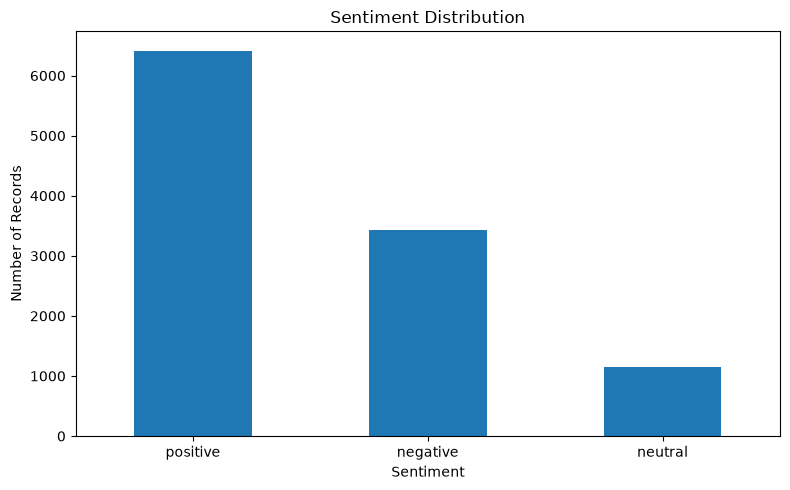

In [56]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Interpretation

The visualization provides an overview of the distribution of sentiment classes in the dataset. This information is important because an imbalanced distribution can affect the interpretation of classification performance.

The class distribution will also be considered when splitting the dataset for model training and testing.

## 4. Text Preprocessing

Text preprocessing is performed to transform raw Indonesian text into a cleaner and more standardized representation before feature extraction and classification.

The preprocessing pipeline consists of four main stages:

1. Case Folding
2. Cleaning
3. Stopword Removal
4. Stemming

These steps are applied sequentially to the text data.


### 4.1 Case Folding

Case folding converts all characters in the text into lowercase letters. This process helps standardize words that differ only in capitalization.

In [57]:
df = train_df.copy()

df["case_folding"] = df["text"].str.lower()

df[["text", "case_folding"]].head()

,text,case_folding
0,warung ini dimiliki oleh pengusaha pabrik tahu...,warung ini dimiliki oleh pengusaha pabrik tahu...
1,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus dan k212 mmbri hujjah partai...
2,lokasi strategis di jalan sumatera bandung . t...,lokasi strategis di jalan sumatera bandung . t...
3,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri ini saat unboxing pake...
4,duh . jadi mahasiswa jangan sombong dong . kas...,duh . jadi mahasiswa jangan sombong dong . kas...


### 4.2 Cleaning

The cleaning stage removes non-alphanumeric characters and unnecessary symbols from the text while preserving letters, numbers, and whitespace.

In [58]:
df["cleaning"] = df["case_folding"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x)
)

df[["case_folding", "cleaning"]].head()

,case_folding,cleaning
0,warung ini dimiliki oleh pengusaha pabrik tahu...,warung ini dimiliki oleh pengusaha pabrik tahu...
1,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus dan k212 mmbri hujjah partai...
2,lokasi strategis di jalan sumatera bandung . t...,lokasi strategis di jalan sumatera bandung te...
3,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri ini saat unboxing pake...
4,duh . jadi mahasiswa jangan sombong dong . kas...,duh jadi mahasiswa jangan sombong dong kasih...


### 4.3 Stopword Removal

Stopword removal removes common words that provide limited discriminative information for sentiment classification.

The Sastrawi library is used to perform Indonesian stopword removal.

In [59]:
stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

df["stopword_removal"] = df["cleaning"].apply(
    lambda x: stopword_remover.remove(x)
)

df[["cleaning", "stopword_removal"]].head()

,cleaning,stopword_removal
0,warung ini dimiliki oleh pengusaha pabrik tahu...,warung dimiliki pengusaha pabrik tahu sudah pu...
1,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus k212 mmbri hujjah partai apa...
2,lokasi strategis di jalan sumatera bandung te...,lokasi strategis jalan sumatera bandung tempa...
3,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri saat unboxing paket ba...
4,duh jadi mahasiswa jangan sombong dong kasih...,duh jadi mahasiswa jangan sombong dong kasih...


In [60]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming_text(text):
    return stemmer.stem(str(text))

In [61]:
from tqdm.auto import tqdm

tqdm.pandas()

df["stemming"] = df["stopword_removal"].progress_apply(stemming_text)

df[[
    "text",
    "case_folding",
    "cleaning",
    "stopword_removal",
    "stemming"
]].head()

  0%|          | 0/11000 [00:00<?, ?it/s]

,text,case_folding,cleaning,stopword_removal,stemming
0,warung ini dimiliki oleh pengusaha pabrik tahu...,warung ini dimiliki oleh pengusaha pabrik tahu...,warung ini dimiliki oleh pengusaha pabrik tahu...,warung dimiliki pengusaha pabrik tahu sudah pu...,warung milik usaha pabrik tahu sudah puluh tah...
1,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus dan k212 mmbri hujjah partai...,mohon ulama lurus k212 mmbri hujjah partai apa...,mohon ulama lurus k212 mmbri hujjah partai apa...
2,lokasi strategis di jalan sumatera bandung . t...,lokasi strategis di jalan sumatera bandung . t...,lokasi strategis di jalan sumatera bandung te...,lokasi strategis jalan sumatera bandung tempa...,lokasi strategis jalan sumatera bandung tempat...
3,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri ini saat unboxing pake...,betapa bahagia nya diri saat unboxing paket ba...,betapa bahagia nya diri saat unboxing paket ba...
4,duh . jadi mahasiswa jangan sombong dong . kas...,duh . jadi mahasiswa jangan sombong dong . kas...,duh jadi mahasiswa jangan sombong dong kasih...,duh jadi mahasiswa jangan sombong dong kasih...,duh jadi mahasiswa jangan sombong dong kasih k...


### Preprocessing Result

After completing the preprocessing stages, the original text has been transformed into a standardized representation. The resulting `stemming` column will be used as the input text for the subsequent feature extraction and classification stages.

## 5. Train-Test Split

The preprocessed dataset is divided into training and testing subsets.

An 80:20 split is used, where:
- 80% of the data is used for training.
- 20% of the data is used for testing.

Stratified sampling is applied to maintain the proportion of each sentiment class in both subsets.

In [62]:
X_text = df["stemming"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train_text))
print("Testing data :", len(X_test_text))

Training data: 8800
Testing data : 2200


## 6. TF-IDF Feature Extraction

Term Frequency-Inverse Document Frequency (TF-IDF) is used to transform the preprocessed text into numerical feature vectors.

TF-IDF assigns higher weights to terms that are important within a document but relatively less frequent across the entire collection of documents.

The TF-IDF vectorizer is fitted only on the training data to prevent information leakage from the testing data.

In [63]:
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape :", X_test.shape)

Training matrix shape: (8800, 5000)
Testing matrix shape : (2200, 5000)


## 7. Naive Bayes

Multinomial Naive Bayes is used as the first baseline classification model.

This algorithm is commonly applied to text classification because it can work effectively with frequency-based and TF-IDF text representations.

The model is trained using the TF-IDF features from the training dataset and evaluated using the testing dataset.

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)
nb_recall = recall_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)
nb_f1 = f1_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)

print("Naive Bayes")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-Score :", nb_f1)

### Classification Report

The classification report provides precision, recall, and F1-score for each sentiment class.

In [64]:
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.74      0.73      0.74       687
     neutral       0.96      0.42      0.59       230
    positive       0.85      0.94      0.89      1283

    accuracy                           0.82      2200
   macro avg       0.85      0.70      0.74      2200
weighted avg       0.83      0.82      0.81      2200



## 8. Logistic Regression

Logistic Regression is used as the second classification model.

Although its name contains the word "regression", Logistic Regression is widely used for classification tasks. In this project, it is used to predict whether a text belongs to the positive, negative, or neutral sentiment category.

In [65]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)
lr_recall = recall_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)
lr_f1 = f1_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

Logistic Regression
Accuracy : 0.8613636363636363
Precision: 0.8597414879810629
Recall   : 0.7948851976491387
F1-Score : 0.8207153363080294


### Classification Report

The classification report is generated to evaluate the performance of Logistic Regression for each sentiment category.

In [66]:
print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.79      0.81      0.80       687
     neutral       0.89      0.65      0.75       230
    positive       0.89      0.93      0.91      1283

    accuracy                           0.86      2200
   macro avg       0.86      0.79      0.82      2200
weighted avg       0.86      0.86      0.86      2200



## 9. Support Vector Machine (SVM)

Linear Support Vector Machine (SVM) is used as the third classical machine learning model.

SVM attempts to find a decision boundary that separates different classes in the feature space. A linear SVM is suitable for high-dimensional text representations such as TF-IDF.

In [67]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)
svm_recall = recall_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)
svm_f1 = f1_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)

print("SVM")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-Score :", svm_f1)

SVM
Accuracy : 0.8572727272727273
Precision: 0.842820899963766
Recall   : 0.8110272281177583
F1-Score : 0.8254852730607487


### Classification Report

The classification report is used to examine the performance of SVM for the three sentiment categories.

In [68]:
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.80      0.79      0.80       687
     neutral       0.84      0.73      0.78       230
    positive       0.89      0.92      0.90      1283

    accuracy                           0.86      2200
   macro avg       0.84      0.81      0.83      2200
weighted avg       0.86      0.86      0.86      2200



## 10. Comparison of Classical Machine Learning Models

The three classical machine learning models are compared using Accuracy, Precision, Recall, and F1-Score.

Macro averaging is used for Precision, Recall, and F1-Score so that each sentiment class contributes equally to the overall metric.

In [70]:
# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)
nb_recall = recall_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)
nb_f1 = f1_score(
    y_test, y_pred_nb, average="macro", zero_division=0
)


# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)
lr_recall = recall_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)
lr_f1 = f1_score(
    y_test, y_pred_lr, average="macro", zero_division=0
)


# Train SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)
svm_recall = recall_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)
svm_f1 = f1_score(
    y_test, y_pred_svm, average="macro", zero_division=0
)

print("All three classical models have been trained successfully.")

All three classical models have been trained successfully.


In [71]:
classical_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        svm_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        svm_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1,
        svm_f1
    ]
})

classical_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.819545,0.850048,0.697410,0.737943
1,Logistic Regression,0.861364,0.859741,0.794885,0.820715
2,SVM,0.857273,0.842821,0.811027,0.825485


## 12. IndoBERT-Lite

IndoBERT-Lite is used as a Transformer-based approach for Indonesian sentiment classification.

Unlike the classical machine learning models that use TF-IDF features, IndoBERT-Lite receives tokenized text and learns contextual representations from the input sequence.

For this experiment, the same 80:20 train-test split is used so that the result can be compared with the classical machine learning models.

### 12.1 Preparing the Dataset

The preprocessed text and sentiment labels are converted into a format that can be processed by the Transformer model.

The sentiment labels are mapped into numerical values:

- Negative → 0
- Neutral → 1
- Positive → 2

In [72]:
from datasets import Dataset

bert_df = pd.DataFrame({
    "text": X_train_text.reset_index(drop=True),
    "label": y_train.reset_index(drop=True).map(label2id)
})

bert_test_df = pd.DataFrame({
    "text": X_test_text.reset_index(drop=True),
    "label": y_test.reset_index(drop=True).map(label2id)
})

train_dataset = Dataset.from_pandas(bert_df)
test_dataset = Dataset.from_pandas(bert_test_df)

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))

Training samples: 8800
Testing samples : 2200


### 12.2 Tokenization

Tokenization converts the preprocessed text into token IDs that can be understood by IndoBERT-Lite.

A maximum sequence length of 64 tokens is used in this experiment.

In [73]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-lite-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/8800 [00:00<?, ? examples/s]

Map:   0%|          | 0/2200 [00:00<?, ? examples/s]

Tokenization completed.


### 12.3 Loading the Classification Model

The pretrained IndoBERT-Lite model is loaded and configured for three-class sentiment classification.

The three output classes represent negative, neutral, and positive sentiment.

In [74]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("IndoBERT-Lite model loaded successfully.")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-lite-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


IndoBERT-Lite model loaded successfully.


### 12.4 Evaluation Metrics

The IndoBERT-Lite model is evaluated using Accuracy, Precision, Recall, and F1-Score.

Macro averaging is used for Precision, Recall, and F1-Score so that each sentiment class receives equal weight.

In [75]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### 12.5 Training Configuration

The model is trained using the following configuration:

- Model: IndoBERT-Lite
- Training data: 8,800 records
- Testing data: 2,200 records
- Maximum sequence length: 64
- Batch size: 8
- Learning rate: 2e-5
- Number of epochs: 1
- Random seed: 42

The one-epoch configuration is used as the benchmark setting for this experiment.

In [76]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./Results/indobert_lite",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    seed=42
)

### 12.6 Model Training

The IndoBERT-Lite model is fine-tuned using the training dataset.

During training, the model adjusts its parameters to classify the input text into negative, neutral, or positive sentiment.

In [77]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.728482,0.739834,0.676818,0.422282,0.467545,0.443169


TrainOutput(global_step=1100, training_loss=0.7760402956875888, metrics={'train_runtime': 773.1292, 'train_samples_per_second': 11.382, 'train_steps_per_second': 1.423, 'total_flos': 26290510540800.0, 'train_loss': 0.7760402956875888, 'epoch': 1.0})

### 12.7 IndoBERT-Lite Evaluation

After fine-tuning, the model is evaluated on the testing dataset.

The evaluation results are used to compare IndoBERT-Lite with the classical machine learning models.

In [78]:
indobert_results = trainer.evaluate()

indobert_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.728482,0.739834,1,0.676818,0.422282,0.467545,0.443169


{'eval_loss': 0.7398338317871094,
 'eval_accuracy': 0.6768181818181818,
 'eval_precision': 0.42228205334282465,
 'eval_recall': 0.46754464287402575,
 'eval_f1': 0.44316942174902313}

## 13. Classification Report for IndoBERT-Lite

The classification report provides a detailed evaluation of the IndoBERT-Lite model for each sentiment category.

Precision, recall, and F1-score are calculated for the negative, neutral, and positive classes.

In [79]:
# Generate predictions
pred_output = trainer.predict(test_tokenized)

y_pred_bert = np.argmax(pred_output.predictions, axis=1)
y_true_bert = np.array(test_tokenized["label"])

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=["negative", "neutral", "positive"],
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.52      0.52      0.52       687
     neutral       0.00      0.00      0.00       230
    positive       0.75      0.88      0.81      1283

    accuracy                           0.68      2200
   macro avg       0.42      0.47      0.44      2200
weighted avg       0.60      0.68      0.63      2200



## 14. Confusion Matrix for IndoBERT-Lite

The confusion matrix is used to examine how IndoBERT-Lite classifies each sentiment category.

The rows represent the actual sentiment labels, while the columns represent the predicted labels.

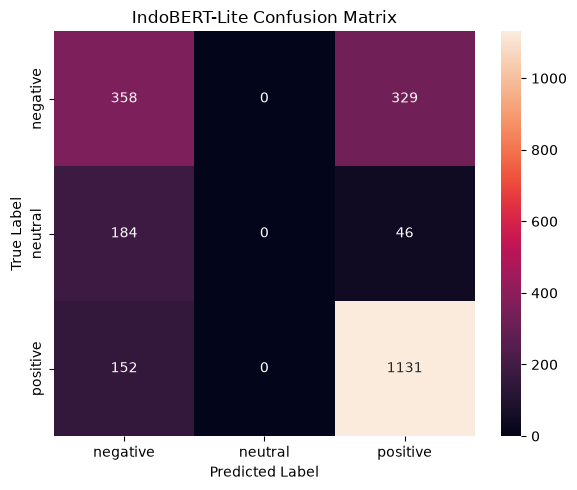

In [80]:
cm_bert = confusion_matrix(
    y_true_bert,
    y_pred_bert,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.title("IndoBERT-Lite Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

## 15. Final Model Comparison

The final comparison combines the results of the three classical machine learning models and IndoBERT-Lite.

The evaluation metrics include Accuracy, Precision, Recall, and F1-Score.

This comparison is intended to provide an overview of the performance obtained under the experimental configurations used in this project.

In [81]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "IndoBERT-Lite"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy,
        indobert_results["eval_accuracy"]
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        svm_precision,
        indobert_results["eval_precision"]
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        svm_recall,
        indobert_results["eval_recall"]
    ],
    "F1-Score": [
        nb_f1,
        lr_f1,
        svm_f1,
        indobert_results["eval_f1"]
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.819545,0.850048,0.697410,0.737943
1,Logistic Regression,0.861364,0.859741,0.794885,0.820715
2,SVM,0.857273,0.842821,0.811027,0.825485
3,IndoBERT-Lite,0.676818,0.422282,0.467545,0.443169


## 16. Model Performance Visualization

A bar chart is created to visually compare the performance of all evaluated models across the four evaluation metrics.

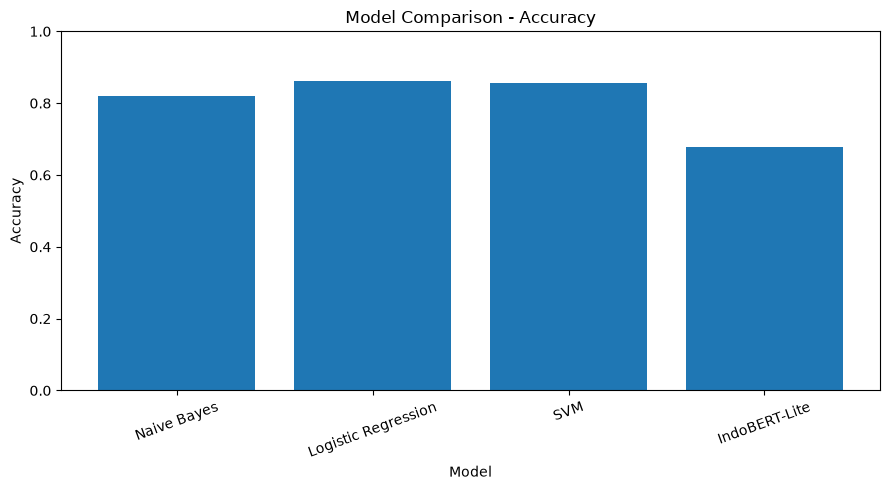

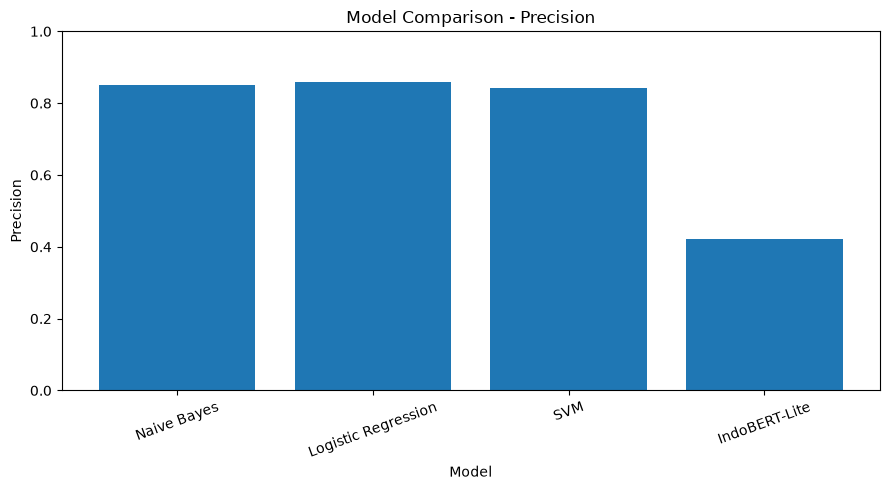

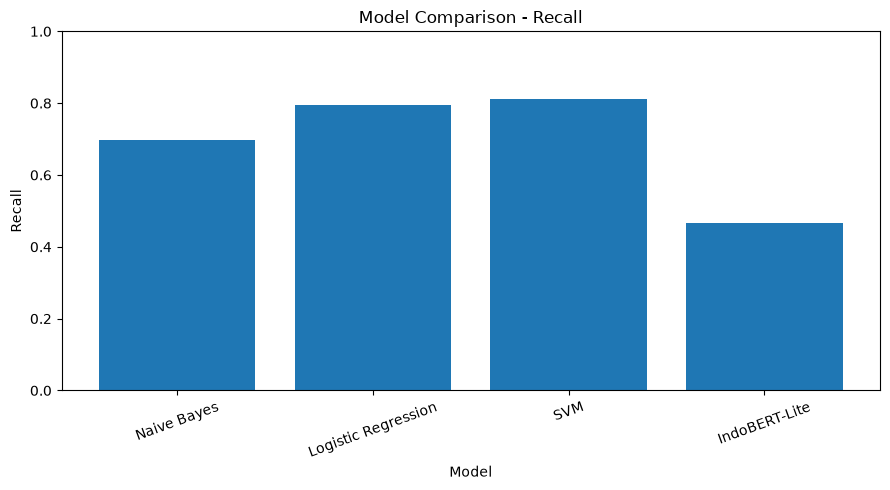

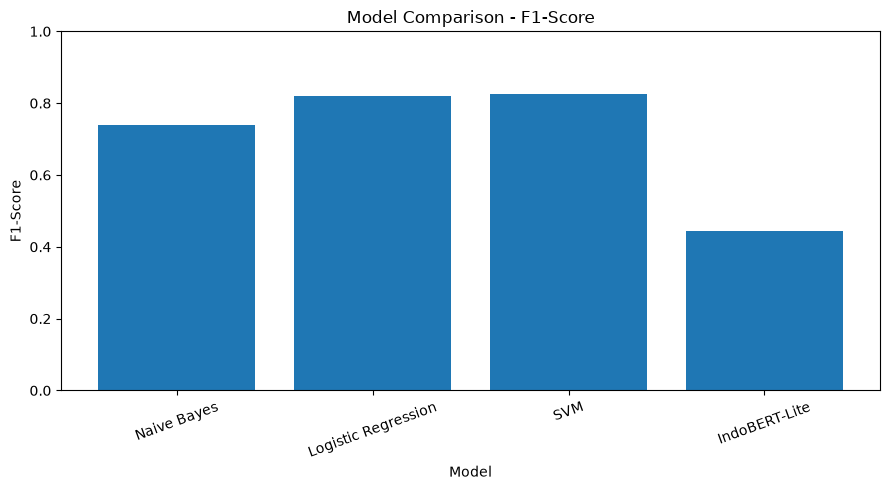

In [82]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics:
    plt.figure(figsize=(9, 5))

    plt.bar(
        final_results["Model"],
        final_results[metric]
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.show()

## 17. Discussion

The experimental results show differences in performance between the classical machine learning models and IndoBERT-Lite.

Among the classical machine learning approaches, Logistic Regression achieved an accuracy of 86.14% and an F1-score of 82.07%. SVM achieved an accuracy of 85.73% and an F1-score of 82.55%, while Naive Bayes achieved an accuracy of 81.95% and an F1-score of 73.79%.

For the IndoBERT-Lite experiment, the model achieved an accuracy of 67.68% and an F1-score of 44.32%. The experiment used one training epoch and a maximum sequence length of 64 tokens.

Based on the experimental configuration, the classical machine learning models produced higher evaluation metrics than IndoBERT-Lite. However, the IndoBERT-Lite result should be interpreted within the specific training configuration used in this experiment. The model was trained for only one epoch, and therefore the result represents the performance obtained under the current benchmark configuration rather than the maximum possible performance of the Transformer model.

The results demonstrate that classical machine learning approaches combined with TF-IDF can provide competitive performance for this dataset, while the Transformer-based approach provides an alternative representation that can be further investigated through additional fine-tuning and optimization.

## 18. Conclusion

This project implemented an end-to-end Indonesian sentiment analysis pipeline consisting of data exploration, text preprocessing, TF-IDF feature extraction, classical machine learning classification, and Transformer-based classification using IndoBERT-Lite.

The classical models evaluated were Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). The models were trained using TF-IDF features and evaluated using Accuracy, Precision, Recall, and F1-Score.

The experiment produced the following results:

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Naive Bayes | 81.95% | 85.00% | 69.74% | 73.79% |
| Logistic Regression | 86.14% | 85.97% | 79.49% | 82.07% |
| SVM | 85.73% | 84.28% | 81.10% | 82.55% |
| IndoBERT-Lite | 67.68% | 42.23% | 46.75% | 44.32% |

Under the experimental configurations used in this project, the classical TF-IDF-based models obtained higher evaluation metrics than the one-epoch IndoBERT-Lite experiment.

Further experiments with different training configurations, such as additional epochs, hyperparameter tuning, and sequence-length adjustments, may be conducted to investigate the performance of IndoBERT-Lite more extensively.